<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Fractal004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

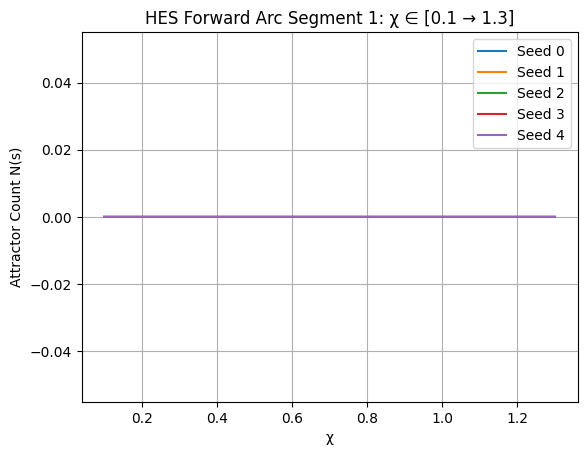

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
Ns = 16       # scale layers
Nx = 32       # spatial grid size
steps = 3000  # time steps
seeds = 5     # bias sweep seeds

# Evolution parameters
beta = 0.8
mu = 0.5
gamma = 1.2
delta = 0.01
chi_vals = np.linspace(0.1, 1.3, steps)

# Metrics to track
results = []

def evolve_phi(phi, chi):
    laplace_xyz = np.roll(phi, 1, axis=1) + np.roll(phi, -1, axis=1) \
                + np.roll(phi, 1, axis=2) + np.roll(phi, -1, axis=2) \
                + np.roll(phi, 1, axis=3) + np.roll(phi, -1, axis=3) - 6 * phi
    laplace_s = np.roll(phi, 1, axis=0) + np.roll(phi, -1, axis=0) - 2 * phi
    dphi_dt = chi * beta * laplace_xyz + mu * laplace_s - beta * phi + gamma * np.tanh(phi)
    dphi_dt += delta * np.random.normal(0, 1, phi.shape)
    return phi + 0.01 * dphi_dt

for seed in range(seeds):
    np.random.seed(seed)
    phi = np.random.normal(1.0, 0.1, (Ns, Nx, Nx, Nx))
    N_mid = []
    S_vals = []
    Lambda_vals = []
    for t in range(steps):
        chi = chi_vals[t]
        phi = evolve_phi(phi, chi)
        mid = phi[Ns // 2]
        N = np.sum(np.abs(mid) > 1.5)
        S = np.mean(np.abs(mid))
        curvature = np.mean(np.gradient(np.gradient(phi, axis=0), axis=0))
        Lambda = chi * curvature
        N_mid.append(N)
        S_vals.append(S)
        Lambda_vals.append(Lambda)
    results.append((N_mid, S_vals, Lambda_vals))

# Plot attractor count across seeds
for i in range(seeds):
    plt.plot(chi_vals, results[i][0], label=f'Seed {i}')
plt.xlabel('χ')
plt.ylabel('Attractor Count N(s)')
plt.title('HES Forward Arc Segment 1: χ ∈ [0.1 → 1.3]')
plt.legend()
plt.grid(True)
plt.show()
